# Reading Habits Analysis
This project explores how demographic characteristics such as age, education, and income relate to reading volume and preferences for print, e-book, and audiobook formats.
This analysis is an updated individual version of a university capstone project originally completed with a partner. The original files are still available for reference.

In [31]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

## Load the Dataset

In [32]:
df = pd.read_csv('reading_habits.csv')

df.head()

,Age,Sex,Race,Marital status?,Education,Employement,Incomes,How many books did you read during last 12months?,Read any printed books during last 12months?,Read any audiobooks during last 12months?,Read any e-books during last 12months?,"Last book you read, you…",Do you happen to read any daily news or newspapers?,Do you happen to read any magazines or journals?
0,66,Male,Refused,Divorced,College graduate,Retired,"$20,000 to under $30,000",97,Yes,No,Yes,Purchased the book,No,Yes
1,46,Male,Native American/American Indian,Married,High school graduate,Employed full-time,"Less than $10,000",97,Yes,Yes,Yes,Purchased the book,Yes,Yes
2,32,Male,Mixed race,Never been married,High school graduate,Employed full-time,"Less than $10,000",97,No,Yes,Yes,Borrowed the book from a friend or family member,Yes,Yes
3,27,Male,Mixed race,Married,High school graduate,Employed full-time,"$40,000 to under $50,000",97,Yes,No,Yes,Borrowed the book from a library,Yes,No
4,16,Female,Mixed race,Never been married,High school incomplete,Employed part-time,"$10,000 to under $20,000",97,Yes,Yes,No,Purchased the book,Yes,No


## Data Overview
Before beginning analysis, I reviewed the dataset's size, column types, missing values, and duplicate records to see what cleaning was needed.

In [33]:
df.shape

(2832, 14)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2832 entries, 0 to 2831
Data columns (total 14 columns):
 #   Column                                               Non-Null Count  Dtype 
---  ------                                               --------------  ----- 
 0   Age                                                  2832 non-null   int64 
 1   Sex                                                  2832 non-null   object
 2   Race                                                 2832 non-null   object
 3   Marital status?                                      2832 non-null   object
 4   Education                                            2774 non-null   object
 5   Employement                                          2832 non-null   object
 6   Incomes                                              2832 non-null   object
 7   How many books did you read during last 12months?    2832 non-null   int64 
 8   Read any printed books during last 12months?         2442 non-null   object
 9

In [35]:
df.isnull().sum()

Age                                                      0
Sex                                                      0
Race                                                     0
Marital status?                                          0
Education                                               58
Employement                                              0
Incomes                                                  0
How many books did you read during last 12months?        0
Read any printed books during last 12months?           390
Read any audiobooks during last 12months?              390
Read any e-books during last 12months?                 390
Last book you read, you…                               390
Do you happen to read any daily news or newspapers?      0
Do you happen to read any magazines or journals?         0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(1)

In [37]:
df.columns

Index(['Age', 'Sex', 'Race', 'Marital status?', 'Education', 'Employement',
       'Incomes', 'How many books did you read during last 12months?',
       'Read any printed books during last 12months?',
       'Read any audiobooks during last 12months?',
       'Read any e-books during last 12months?', 'Last book you read, you…',
       'Do you happen to read any daily news or newspapers?',
       'Do you happen to read any magazines or journals?'],
      dtype='object')

## Data Cleaning
To make the dataset easier to work with, I renamed several columns, checked the duplicate record, and investigated missing values.

In [38]:
df = df.rename(columns={
    "Age": "age",
    "Sex": "sex",
    "Race": "race",
    "Marital status?": "marital_status",
    "Education": "education",
    "Employement": "employment",
    "Incomes": "income",
    "How many books did you read during last 12months?": "books_read",
    "Read any printed books during last 12months?": "printed",
    "Read any audiobooks during last 12months?": "audiobook",
    "Read any e-books during last 12months?": "ebook",
    "Last book you read, you…": "last_book_format",
    "Do you happen to read any daily news or newspapers?": "daily_news",
    "Do you happen to read any magazines or journals?": "magazines"
})

In [39]:
df = df.drop_duplicates().copy()

df.shape

(2831, 14)

In [40]:
format_cols = [
    "printed",
    "audiobook",
    "ebook",
    "last_book_format"
]

df[format_cols].isna().all(axis=1).sum()

np.int64(390)

In [41]:
df.loc[
    df[format_cols].isna().all(axis=1),
    "books_read"
].value_counts().sort_index()

books_read
0    390
Name: count, dtype: int64

In [42]:
df["education"].value_counts(dropna=False)

education
High school graduate                                        688
Some college, no 4-year degree                              651
College graduate                                            596
Post-graduate training/professional school after college    501
High school incomplete                                      263
Technical, trade or vocational school AFTER high school      66
NaN                                                          58
Don’t know                                                    8
Name: count, dtype: int64

In [43]:
df.loc[
    df["books_read"] == 0,
    format_cols
] = df.loc[
    df["books_read"] == 0,
    format_cols
].fillna("Not applicable")

In [44]:
df[format_cols].isnull().sum()

printed             0
audiobook           0
ebook               0
last_book_format    0
dtype: int64

In [45]:
df["income"] = df["income"].replace(
    "9$100,000 to under $150,000",
    "$100,000 to under $150,000"
)

In [46]:
df["income"].value_counts()

income
$100,000 to under $150,000    742
$50,000 to under $75,000      394
$75,000 to under $100,000     315
Refused                       291
$30,000 to under $40,000      265
$20,000 to under $30,000      238
$10,000 to under $20,000      216
$40,000 to under $50,000      207
Less than $10,000             163
Name: count, dtype: int64

In [47]:
df["last_book_format"] = df["last_book_format"].replace(
    ["8", "9"],
    "Unspecified"
)

In [48]:
df["last_book_format"].value_counts(dropna=False)

last_book_format
Purchased the book                                  1265
Borrowed the book from a friend or family member     501
Not applicable                                       390
Borrowed the book from a library                     335
Got the book some other way                          309
Unspecified                                           31
Name: count, dtype: int64

### Data Cleaning Summary

The dataset originally contained 2,832 records. One duplicate was removed, leaving 2,831 records for analysis.

The reading-format columns contained 390 missing responses, all belonging to individuals who reported reading 0 books during the previous 12 months. These values were labeled as "Not applicable" rather than removing the records.

A formatting error in the income column was corrected by changing `9$100,000 to under $150,000` to `$100,000 to under $150,000`.

The `last_book_format` column also contained 31 coded responses labeled `8` or `9`. Because their meaning could not be confirmed from the available dataset information, these values were grouped as "Unspecified."

Education contained 58 missing values and 8 "Don’t know" responses. These records were retained in the dataset but will be excluded from analyses that specifically compare education levels.

## Descriptive Statistics
I calculated summary statistics to get a general sense of the participants and their reading behavior before looking at relationships between variables.

In [49]:
df[["age","books_read"]].describe()

,age,books_read
count,2831.000000,2831.000000
mean,47.270223,16.677852
std,18.565806,23.636082
min,16.000000,0.000000
25%,32.000000,2.500000
50%,48.000000,6.000000
75%,62.000000,20.000000
max,93.000000,97.000000


In [50]:
df[[
    "sex",
    "race",
    "education",
    "employment",
    "income"
]].describe(include="object")

,sex,race,education,employment,income
count,2831,2831,2773,2831,2831
unique,2,8,7,8,9
top,Female,White,High school graduate,Employed full-time,"$100,000 to under $150,000"
freq,1479,2216,688,1238,742


In [51]:
avg_age = df.age.mean()
avg_books = df.books_read.mean()
median_books = df.books_read.median()

print(f"Average age: {avg_age:.1f} years")
print(f"Average books read: {avg_books:.1f}")
print(f"Median books read: {median_books:.1f}")

Average age: 47.3 years
Average books read: 16.7
Median books read: 6.0


### Summary
Participants had an average age of 47.3 years. The average number of books read in the last 12 months was 16.7, while the median was only 6 books.
The large differnce between the mean and median suggests that reading volume is right-skewed, with a smaller group of participants reporting much higher number of books read.
The dataset also includes a mix of demographic groups, although some categories are much more common than others. 

## Distribution of Books Read
To better understand overall reading behavior, I examined the distribution of the number of books participants reported reading during the previous 12 months.

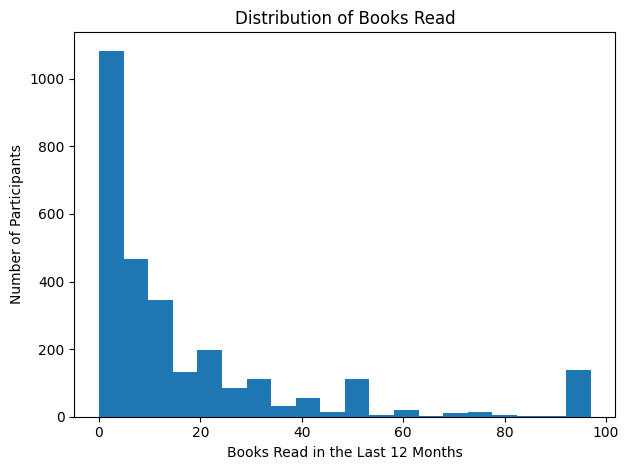

In [52]:
plt.hist(df.books_read, bins=20)

plt.title("Distribution of Books Read")
plt.xlabel("Books Read in the Last 12 Months")
plt.ylabel("Number of Participants")
plt.tight_layout()

plt.show()

In [53]:
print(f"Mean books read: {df['books_read'].mean():.1f}")
print(f"Median books read: {df['books_read'].median():.1f}")
print(f"Participants who read 0 books: {(df['books_read'] == 0).sum()}")
print(f"Share who read 0 books: {(df['books_read'] == 0).mean() * 100:.1f}%")

Mean books read: 16.7
Median books read: 6.0
Participants who read 0 books: 390
Share who read 0 books: 13.8%


In [57]:
max_books = df["books_read"].max()
max_count = (df["books_read"] == max_books).sum()

print(f"Maximum recorded books: {max_books}")
print(f"Participants at maximum: {max_count}")

Maximum recorded books: 97
Participants at maximum: 124


### Finding

The number of books read is strongly right-skewed. The median participant read 6 books during the previous 12 months, while the mean was much higher at 16.7 books.
A total of 390 participants, or 13.8% of the dataset, reported reading no books. The distribution also contains a smaller group of very high-volume readers, including 124 responses at the maximum recorded value of 97 books.
Because these high values pull the mean upward, the median provides a better representation of a typical participant's reading volume. The available dataset documentation does not clarify whether the value of 97 represents an exact response or a capped survey value, so it was retained rather than altered.